# Visualising ACTRIS data with Providentia

## Import libraries

In [1]:
%matplotlib inline

In [2]:
import sys
sys.path.append('/tljh-home/felles/providentia')

In [3]:
import providentia as prv

## Load configuration file

We are going to load hourly data for ozone mass concentration from the ACTRIS framework for the year 2018.

In [4]:
provi = prv.Providentia('actris_vre.conf')

In [5]:
provi.print_config()

[ACTRIS]
framework = actris/actris
species = ozone mass concentration
resolution = hourly
start_date = 20180101
end_date = 20190101
report_type = standard
report_summary = True
report_stations = False
report_filename = PROVIDENTIA_Report
report_title = Report
observations_data_label = Ozone Mass Concentration


## Download data

Now we format and download the data from NILU Thredds server (`https://thredds.nilu.no/thredds/catalog/ebas_doi/catalog.html`) into the path defined in `settings/data_paths.json` for local machines.

In [6]:
provi.download()

Starting Providentia download...

----------------------------------------


  - /home/pserrano/data/providentia/obs/nonghost/actris/actris/hourly/sconco3, source: https://prod-actris-md.nilu.no/metadata/content/ozone mass concentration


    Processing station data: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 169/169

    === WARNINGS (7) ===
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/6F/E3/MN/6FE3-MNQZ.nc (GB0053R): No data available after filtering by time.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/PP/2Z/CJ/PP2Z-CJMY.nc (CZ0003R): Taking data from first height (Tower_inlet_height=8.0). 
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/K2/9Z/6P/K29Z-6PPE.nc (GB0059G): No data available after filtering by time.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/95/JM/3P/95JM-3P3T.nc (EG0001U): No data available after filtering by time.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/G2/64/Q3/G264-Q3K5.nc (GR0001R): No data after temporal averaging.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/S3/89/JQ/S389-JQAJ.nc (DE0060G): No data available after filtering by time.
    https://thredds.nilu.no/thredds/dodsC/ebas_doi/SE/D6/56/SED6-5637.nc (NO0047R): No data available after filtering by time.


## Read data

It is time to explore the data, for this we need to first load it in memory.

In [7]:
provi.load()

Updating file tree /home/pserrano/providentia/settings/internal/ghost_filetree_1.5.json...
Updating file tree /home/pserrano/providentia/settings/internal/nonghost_filetree.json...
Reading data

OBSERVATIONS
 - actris/actris|sconco3

Resetting data filters to when class was initialised, loading ACTRIS subsection filters.
Filtering data


In [8]:
data = provi.data(format='xr')
data

<xarray.Dataset> Size: 12MB
Dimensions:                                                     (data_label: 1,
                                                                 station_actris_actris|sconco3: 163,
                                                                 time: 8760,
                                                                 month: 12)
Coordinates:
  * time                                                        (time) datetime64[ns] 70kB ...
Dimensions without coordinates: data_label, station_actris_actris|sconco3, month
Data variables: (12/27)
    data_labels                                                 (data_label) <U24 96B ...
    actris_actris|sconco3_data                                  (data_label, station_actris_actris|sconco3, time) float32 6MB ...
    actris_actris|sconco3_station_reference                     (station_actris_actris|sconco3, month) <U7 55kB ...
    actris_actris|sconco3_longitude                             (station_actris_actris|sconco3, month) float64 16kB ...
    actris_actris|sconco3_latitude                              (station_actris_actris|sconco3, month) float64 16kB ...
    actris_actris|sconco3_station_name                          (station_actris_actris|sconco3, month) <U53 415kB ...
    ...                                                          ...
    actris_actris|sconco3_principal_investigator_email_address  (station_actris_actris|sconco3, month) <U75 587kB ...
    actris_actris|sconco3_contact_name                          (station_actris_actris|sconco3, month) <U75 587kB ...
    actris_actris|sconco3_contact_institution                   (station_actris_actris|sconco3, month) <U75 587kB ...
    actris_actris|sconco3_contact_email_address                 (station_actris_actris|sconco3, month) <U75 587kB ...
    actris_actris|sconco3_doi                                   (station_actris_actris|sconco3, month) <U34 266kB ...
    actris_actris|sconco3_actris_national_facility              (station_actris_actris|sconco3, month) <U5 39kB ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

The variable data is stored in `actris_actris|sconco3_data` by label (in this case only observations), station and time.

In [9]:
data['actris_actris|sconco3_data']

<xarray.DataArray 'actris_actris|sconco3_data' (data_label: 1,
                                                station_actris_actris|sconco3: 163,
                                                time: 8760)> Size: 6MB
array([[[   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan,    nan,    nan, ..., 27.715, 23.645, 27.775],
        [   nan,    nan,    nan, ...,    nan,    nan,    nan],
        ...,
        [   nan, 51.639, 53.575, ...,    nan,    nan,    nan],
        [51.919, 40.366, 37.313, ..., 51.52 , 54.094, 51.28 ],
        [38.91 , 34.12 , 34.72 , ..., 37.51 , 36.51 , 35.32 ]]],
      shape=(1, 163, 8760), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2018-01-01 ... 2018-12-31T23:00:00
Dimensions without coordinates: data_label, station_actris_actris|sconco3
Attributes: (12/26)
    standard_name:                            ozone
    long_name:                                ozone
    units:                                    nmol mol-1
    description:                              Measured value of surface ozone...
    resolution:                               hourly
    resampling_resolution:                    None
    ...                                       ...
    spatial_colocation_station_reference:     True
    spatial_colocation_station_name:          True
    spatial_colocation_longitude_latitude:    True
    spatial_colocation_measurement_altitude:  True
    spatial_colocation_validation:            True
    spatial_colocation_validation_tolerance:  10000.0

While the station information is stored in different variables by month, such as `actris_actris|sconco3_station_reference`, `actris_actris|sconco3_station_name`, `actris_actris|sconco3_latitude` and `actris_actris|sconco3_longitude`.

In [10]:
data['actris_actris|sconco3_station_reference']

<xarray.DataArray 'actris_actris|sconco3_station_reference' (
                                                             station_actris_actris|sconco3: 163,
                                                             month: 12)> Size: 55kB
array([['nan', 'nan', 'nan', ..., 'AR0001R', 'AR0001R', 'AR0001R'],
       ['nan', 'AR0002G', 'AR0002G', ..., 'AR0002G', 'AR0002G',
        'AR0002G'],
       ['nan', 'nan', 'nan', ..., 'AR0004R', 'AR0004R', 'nan'],
       ...,
       ['US6005G', 'US6005G', 'US6005G', ..., 'nan', 'nan', 'nan'],
       ['VN0001R', 'VN0001R', 'VN0001R', ..., 'VN0001R', 'VN0001R',
        'VN0001R'],
       ['ZA0001G', 'ZA0001G', 'ZA0001G', ..., 'ZA0001G', 'ZA0001G',
        'ZA0001G']], shape=(163, 12), dtype='<U7')
Dimensions without coordinates: station_actris_actris|sconco3, month
Attributes:
    standard_name:  station reference
    long_name:      station reference identifier
    units:          unitless
    description:    reference ID for station.

In [11]:
data['actris_actris|sconco3_station_name']

<xarray.DataArray 'actris_actris|sconco3_station_name' (
                                                        station_actris_actris|sconco3: 163,
                                                        month: 12)> Size: 415kB
array([['nan', 'nan', 'nan', ..., 'Marambio', 'Marambio', 'Marambio'],
       ['nan', 'Ushuaia', 'Ushuaia', ..., 'Ushuaia', 'Ushuaia',
        'Ushuaia'],
       ['nan', 'nan', 'nan', ..., 'La Quiaca', 'La Quiaca', 'nan'],
       ...,
       ['Trinidad Head', 'Trinidad Head', 'Trinidad Head', ..., 'nan',
        'nan', 'nan'],
       ['Pha Din', 'Pha Din', 'Pha Din', ..., 'Pha Din', 'Pha Din',
        'Pha Din'],
       ['Cape Point', 'Cape Point', 'Cape Point', ..., 'Cape Point',
        'Cape Point', 'Cape Point']], shape=(163, 12), dtype='<U53')
Dimensions without coordinates: station_actris_actris|sconco3, month
Attributes:
    standard_name:  station name
    long_name:      station name
    units:          unitless
    description:    Name of station where the measurement was conducted.

In [12]:
data['actris_actris|sconco3_latitude']

<xarray.DataArray 'actris_actris|sconco3_latitude' (
                                                    station_actris_actris|sconco3: 163,
                                                    month: 12)> Size: 16kB
array([[         nan,          nan,          nan, ..., -64.24006   ,
        -64.24006   , -64.24006   ],
       [         nan, -54.84846497, -54.84846497, ..., -54.84846497,
        -54.84846497, -54.84846497],
       [         nan,          nan,          nan, ..., -22.10333333,
        -22.10333333,          nan],
       ...,
       [ 41.05410004,  41.05410004,  41.05410004, ...,          nan,
                 nan,          nan],
       [ 21.5731    ,  21.5731    ,  21.5731    , ...,  21.5731    ,
         21.5731    ,  21.5731    ],
       [-34.35348   , -34.35348   , -34.35348   , ..., -34.35348   ,
        -34.35348   , -34.35348   ]], shape=(163, 12))
Dimensions without coordinates: station_actris_actris|sconco3, month
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          decimal degrees North
    description:    Geodetic latitude of measuring instrument, in decimal deg...
    axis:           Y

In [13]:
data['actris_actris|sconco3_longitude']

<xarray.DataArray 'actris_actris|sconco3_longitude' (
                                                     station_actris_actris|sconco3: 163,
                                                     month: 12)> Size: 16kB
array([[          nan,           nan,           nan, ...,  -56.62478   ,
         -56.62478   ,  -56.62478   ],
       [          nan,  -68.31069183,  -68.31069183, ...,  -68.31069183,
         -68.31069183,  -68.31069183],
       [          nan,           nan,           nan, ...,  -65.60083333,
         -65.60083333,           nan],
       ...,
       [-124.15100098, -124.15100098, -124.15100098, ...,           nan,
                  nan,           nan],
       [ 103.5157    ,  103.5157    ,  103.5157    , ...,  103.5157    ,
         103.5157    ,  103.5157    ],
       [  18.48968   ,   18.48968   ,   18.48968   , ...,   18.48968   ,
          18.48968   ,   18.48968   ]], shape=(163, 12))
Dimensions without coordinates: station_actris_actris|sconco3, month
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          decimal degrees East
    description:    Geodetic longitude of measuring instrument, in decimal de...
    axis:           X

## Save data

Data can be saved as netCDF or Numpy.

### Save to netCDF

In [14]:
provi.save(format='nc')

Data saved to /home/pserrano/providentia/saved_data/PRV_20260119_1503.nc


### Save to Numpy

In [15]:
provi.save(format='np')

Data saved to /home/pserrano/providentia/saved_data/PRV_20260119_1503.npz


## Plot

The statistics that can be plotted are: `Mean`, `Median`, `StdDev`, `Var`, `Min`, `Max`, `NData`, `Data%`, `NStations`, `Exceedances`, `p1`, `p5`, `p10`, `p25`, `p75` , `p90`, `p95`, `p99` and `MDA8`.

### Maps

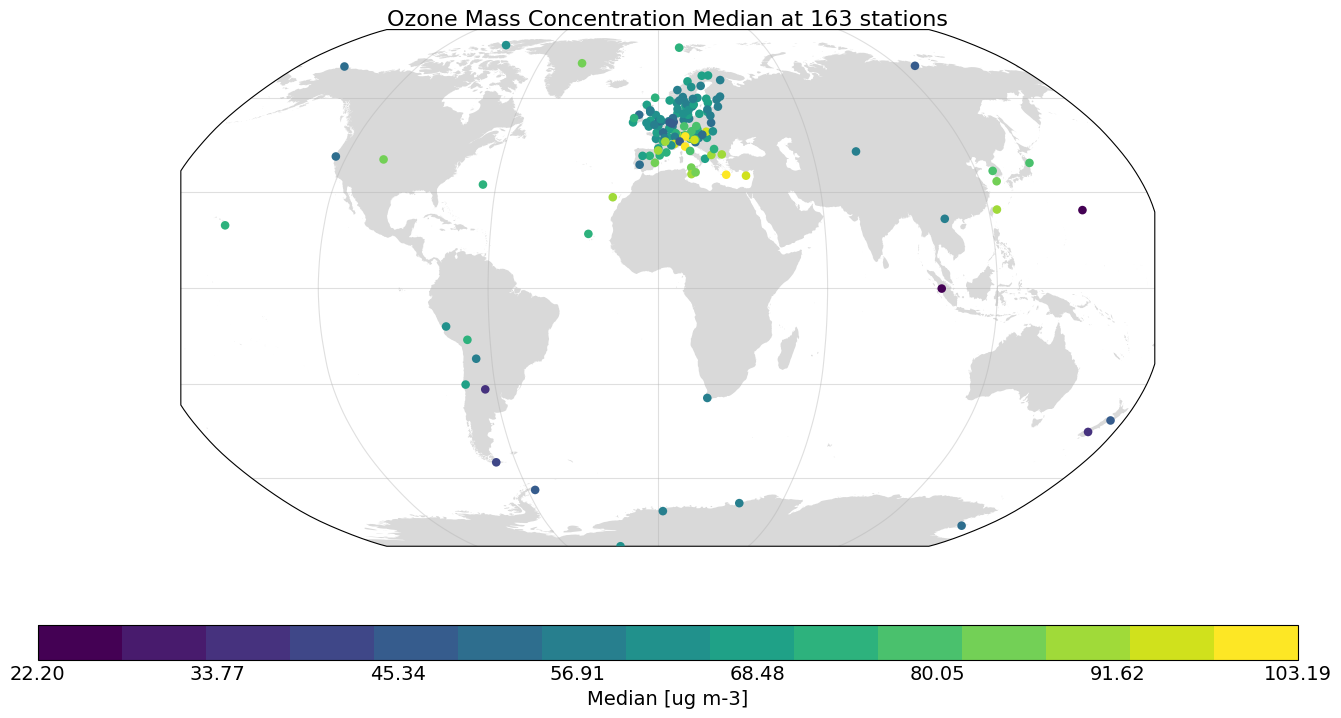

In [16]:
provi.plot('map-Median')

### Timeseries

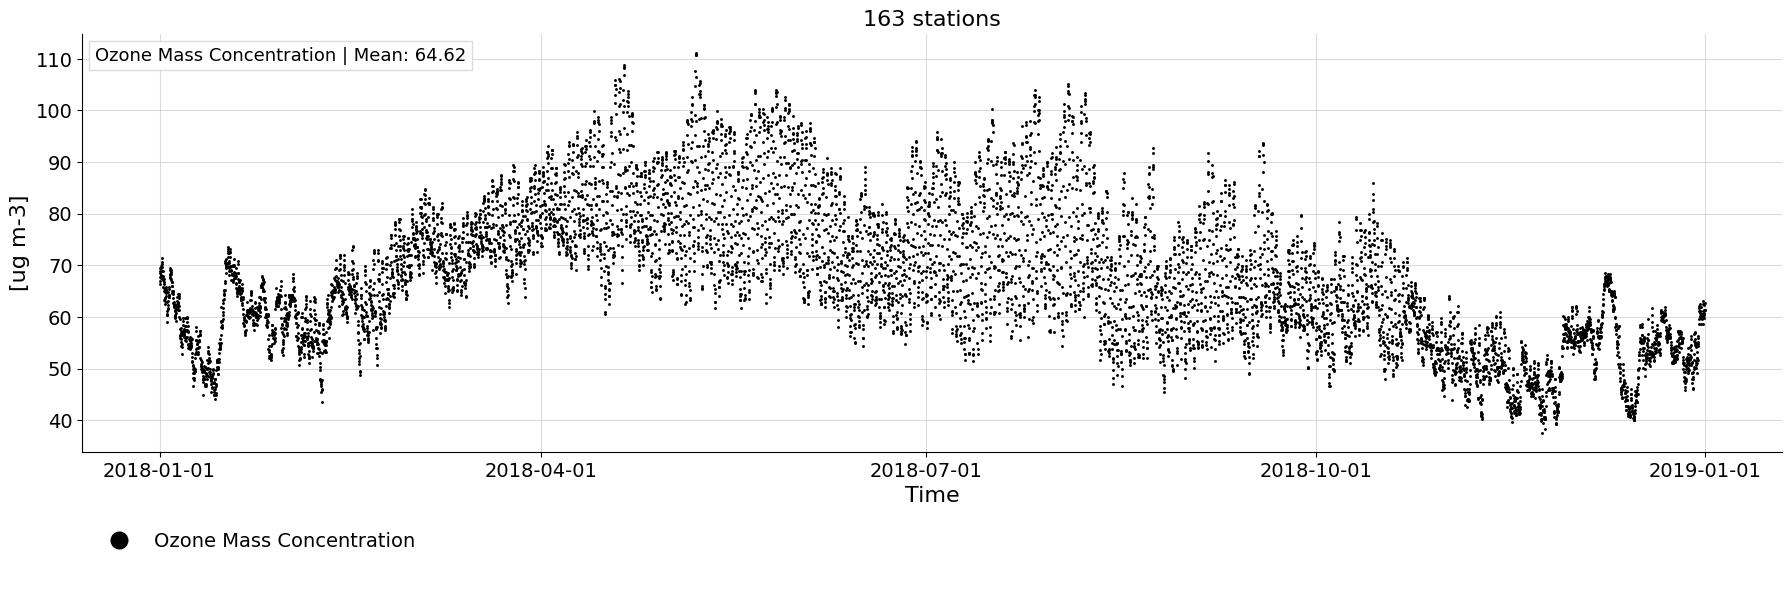

In [17]:
provi.plot('timeseries', annotate=True)

### Periodic plots

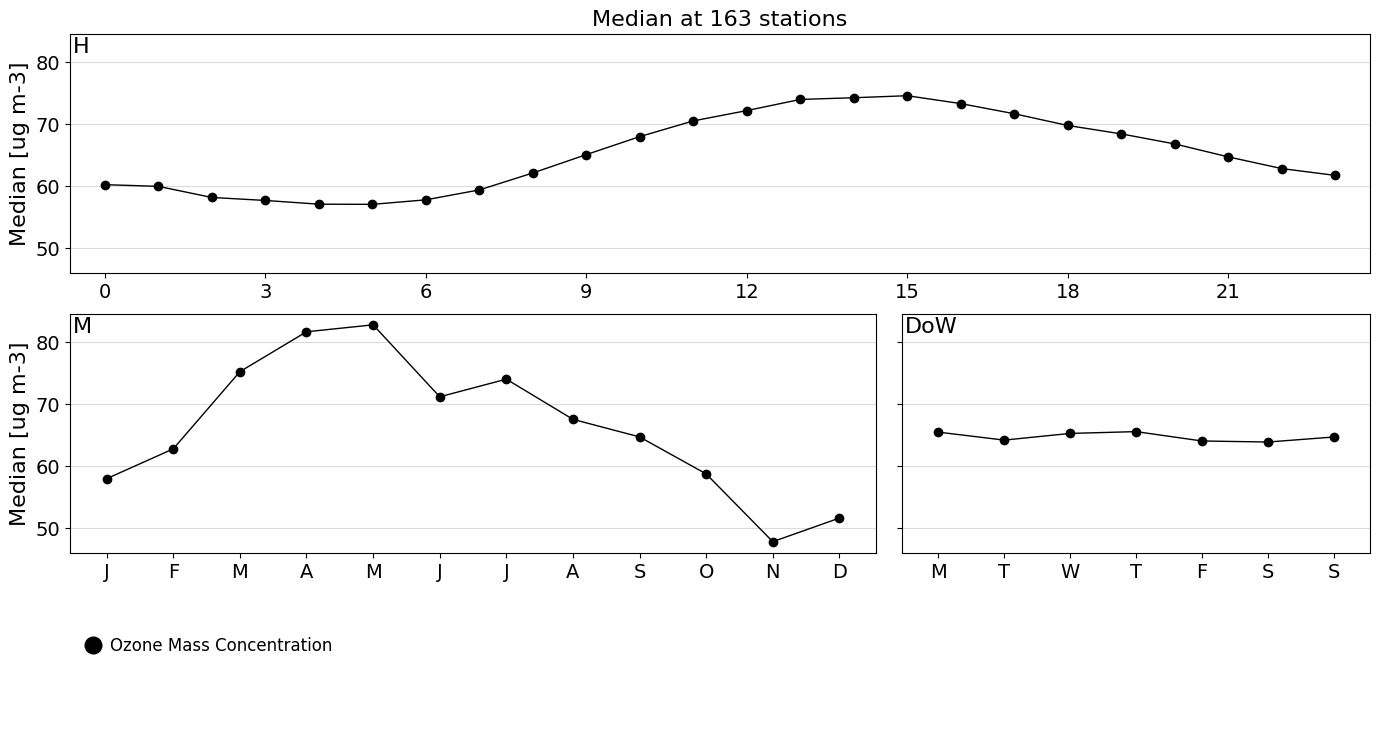

In [18]:
provi.plot('periodic-Median')

### Periodic violin plots

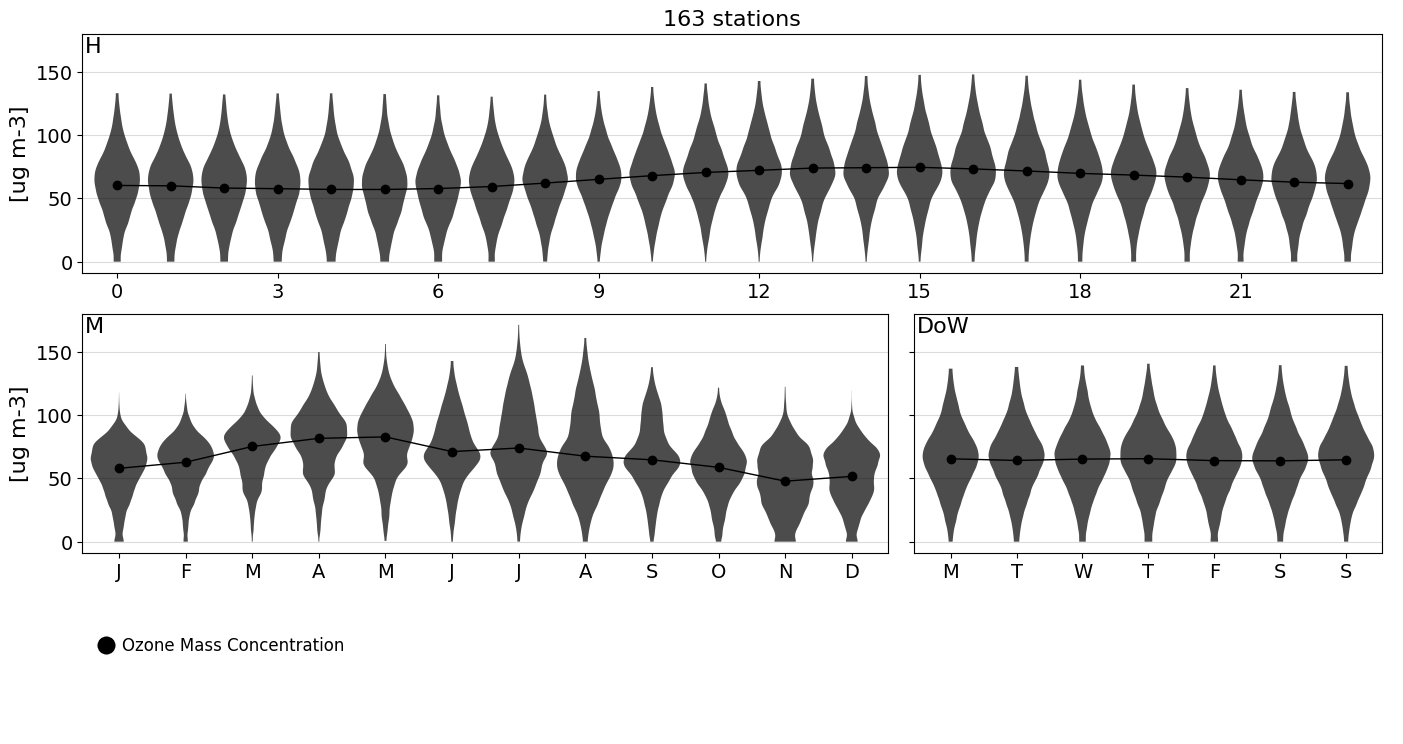

In [19]:
provi.plot('periodic-violin')

### Distribution plots

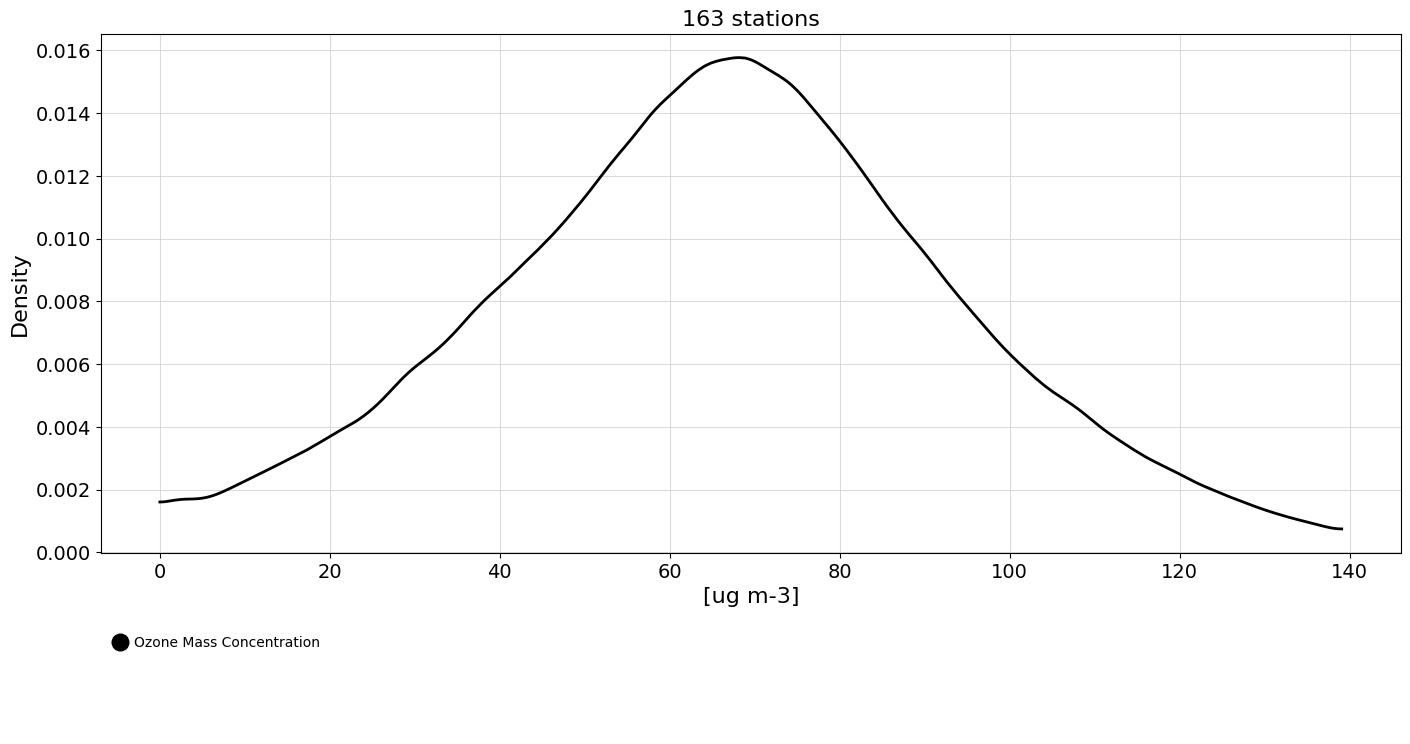

In [20]:
provi.plot('distribution')

### Boxplot

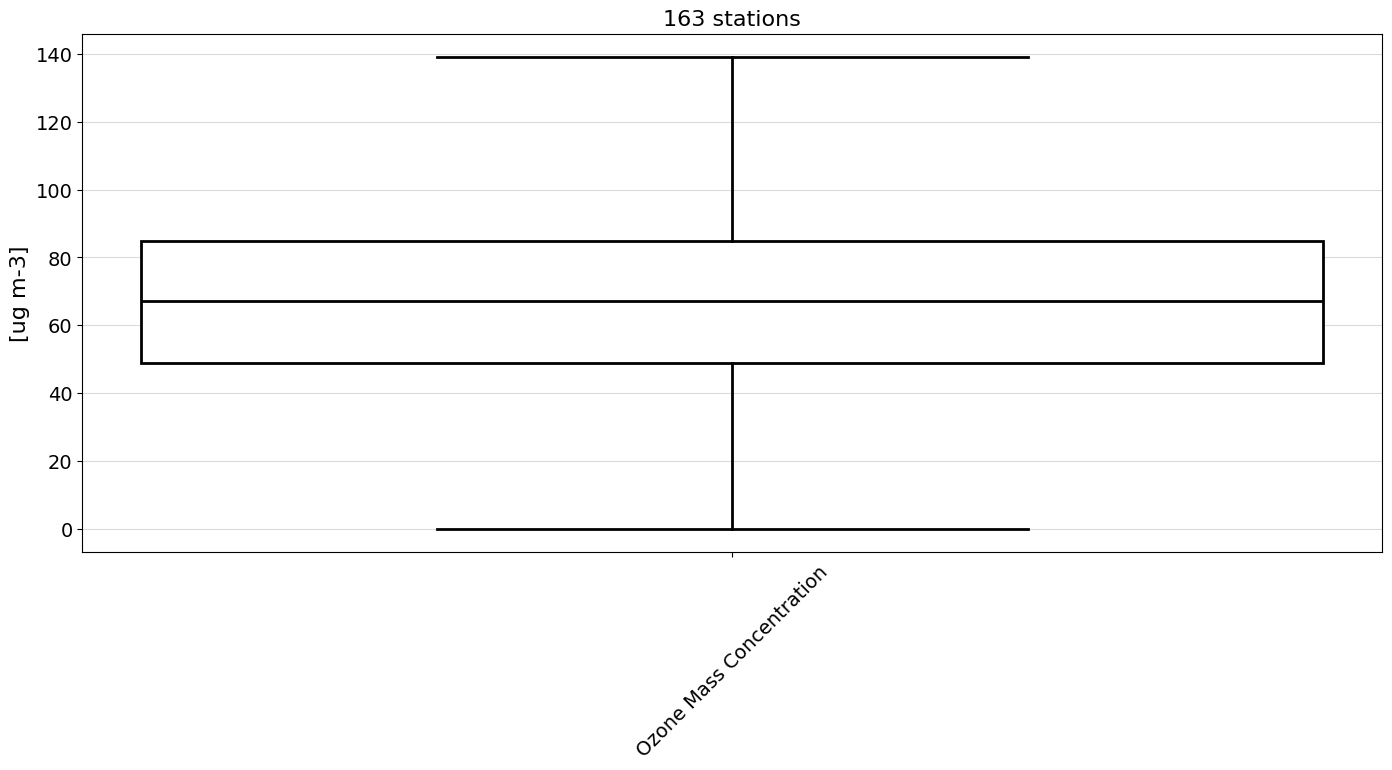

In [21]:
provi.plot('boxplot')

## Filter data

### By country

We can use the metadata to easily filter by country. In this case, we will select all stations in France and United Kingdom.

In [22]:
# filter data by country metadata 
provi.reset()
provi.filter('country', keep=['France','United Kingdom'])
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 2MB
Dimensions:                                                     (data_label: 1,
                                                                 station_actris_actris|sconco3: 29,
                                                                 time: 8760,
                                                                 month: 12)
Coordinates:
  * time                                                        (time) datetime64[ns] 70kB ...
Dimensions without coordinates: data_label, station_actris_actris|sconco3, month
Data variables: (12/27)
    data_labels                                                 (data_label) <U24 96B ...
    actris_actris|sconco3_data                                  (data_label, station_actris_actris|sconco3, time) float32 1MB ...
    actris_actris|sconco3_station_reference                     (station_actris_actris|sconco3, month) <U7 10kB ...
    actris_actris|sconco3_longitude                             (station_actris_actris|sconco3, month) float64 3kB ...
    actris_actris|sconco3_latitude                              (station_actris_actris|sconco3, month) float64 3kB ...
    actris_actris|sconco3_station_name                          (station_actris_actris|sconco3, month) <U38 53kB ...
    ...                                                          ...
    actris_actris|sconco3_principal_investigator_email_address  (station_actris_actris|sconco3, month) <U56 78kB ...
    actris_actris|sconco3_contact_name                          (station_actris_actris|sconco3, month) <U46 64kB ...
    actris_actris|sconco3_contact_institution                   (station_actris_actris|sconco3, month) <U75 104kB ...
    actris_actris|sconco3_contact_email_address                 (station_actris_actris|sconco3, month) <U56 78kB ...
    actris_actris|sconco3_doi                                   (station_actris_actris|sconco3, month) <U34 47kB ...
    actris_actris|sconco3_actris_national_facility              (station_actris_actris|sconco3, month) <U5 7kB ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

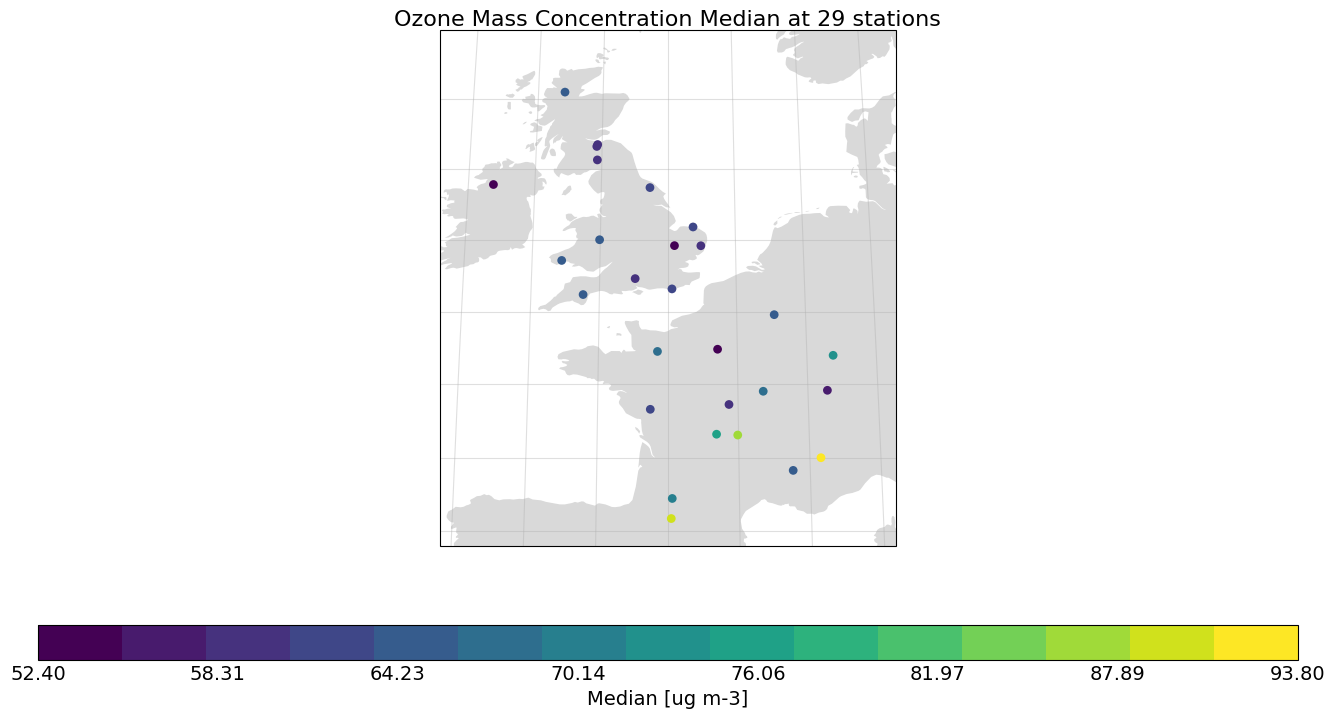

In [23]:
provi.plot('map-Median', map_extent=[-10, 10, 42, 60])

### By altitude

Now we reset the filters, and filter by altitudes of at least 2000m.

In [24]:
# filter data by station altitude
provi.reset()
provi.filter('altitude', lower=2000)
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 869kB
Dimensions:                                                     (data_label: 1,
                                                                 station_actris_actris|sconco3: 14,
                                                                 time: 8760,
                                                                 month: 12)
Coordinates:
  * time                                                        (time) datetime64[ns] 70kB ...
Dimensions without coordinates: data_label, station_actris_actris|sconco3, month
Data variables: (12/27)
    data_labels                                                 (data_label) <U24 96B ...
    actris_actris|sconco3_data                                  (data_label, station_actris_actris|sconco3, time) float32 491kB ...
    actris_actris|sconco3_station_reference                     (station_actris_actris|sconco3, month) <U7 5kB ...
    actris_actris|sconco3_longitude                             (station_actris_actris|sconco3, month) float64 1kB ...
    actris_actris|sconco3_latitude                              (station_actris_actris|sconco3, month) float64 1kB ...
    actris_actris|sconco3_station_name                          (station_actris_actris|sconco3, month) <U26 17kB ...
    ...                                                          ...
    actris_actris|sconco3_principal_investigator_email_address  (station_actris_actris|sconco3, month) <U31 21kB ...
    actris_actris|sconco3_contact_name                          (station_actris_actris|sconco3, month) <U38 26kB ...
    actris_actris|sconco3_contact_institution                   (station_actris_actris|sconco3, month) <U51 34kB ...
    actris_actris|sconco3_contact_email_address                 (station_actris_actris|sconco3, month) <U31 21kB ...
    actris_actris|sconco3_doi                                   (station_actris_actris|sconco3, month) <U34 23kB ...
    actris_actris|sconco3_actris_national_facility              (station_actris_actris|sconco3, month) <U5 3kB ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

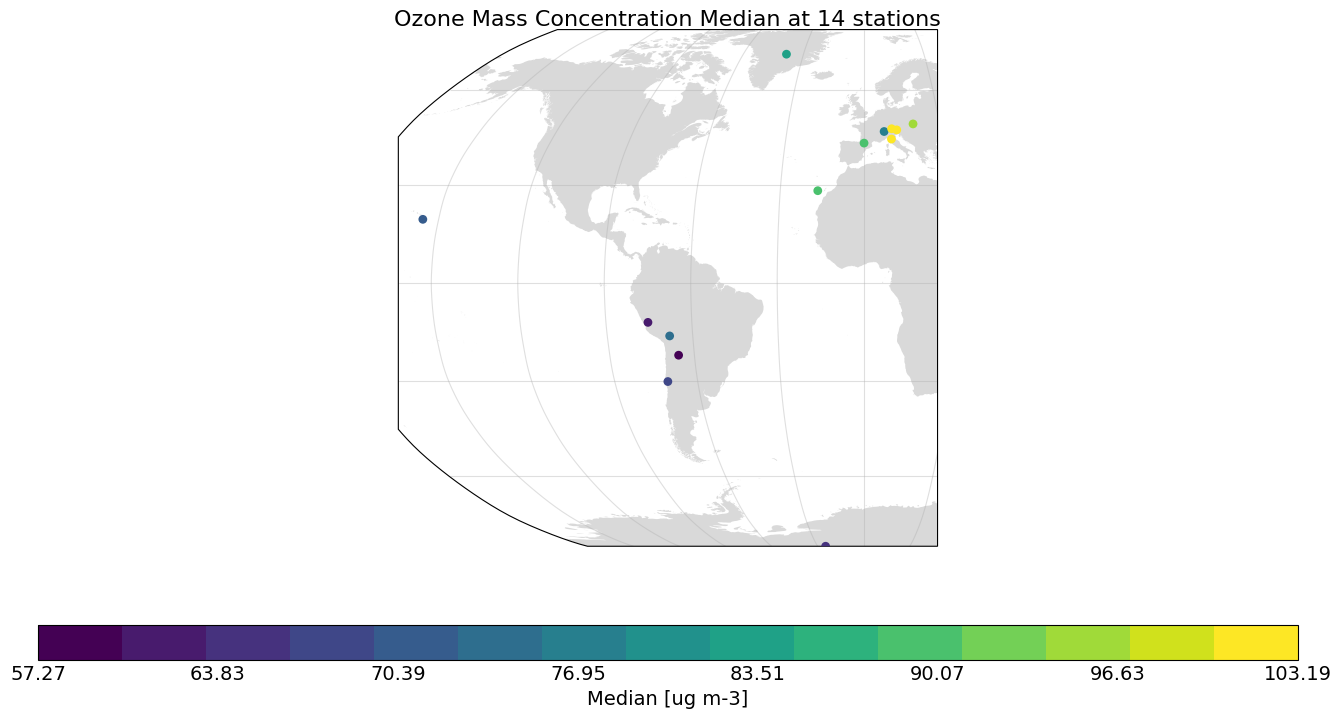

In [25]:
provi.plot('map-Median')

### By station reference

In [26]:
stations_data['actris_actris|sconco3_station_reference']

<xarray.DataArray 'actris_actris|sconco3_station_reference' (
                                                             station_actris_actris|sconco3: 14,
                                                             month: 12)> Size: 5kB
array([['nan', 'nan', 'nan', 'nan', 'nan', 'AR0004R', 'AR0004R',
        'AR0004R', 'AR0004R', 'AR0004R', 'AR0004R', 'nan'],
       ['AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G',
        'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G', 'AT0034G'],
       ['nan', 'nan', 'nan', 'BO0001R', 'BO0001R', 'BO0001R', 'BO0001R',
        'BO0001R', 'BO0001R', 'BO0001R', 'BO0001R', 'BO0001R'],
       ['CH0001G', 'CH0001G', 'CH0001G', 'CH0001G', 'CH0001G', 'CH0001G',
        'CH0001G', 'CH0001G', 'CH0001G', 'CH0001G', 'CH0001G', 'CH0001G'],
       ['CL0001R', 'CL0001R', 'CL0001R', 'CL0001R', 'CL0001R', 'CL0001R',
        'CL0001R', 'CL0001R', 'CL0001R', 'CL0001R', 'CL0001R', 'CL0001R'],
       ['nan', 'DE0054R', 'DE0054R', 'DE0054R', 'DE0054R', 'DE0054R',
        'DE0054R', 'DE0054R', 'DE0054R', 'DE0054R', 'DE0054R', 'DE0054R'],
       ['DK0025G', 'DK0025G', 'DK0025G', 'DK0025G', 'DK0025G', 'DK0025G',
        'DK0025G', 'DK0025G', 'DK0025G', 'DK0025G', 'DK0025G', 'DK0025G'],
       ['ES0018G', 'ES0018G', 'ES0018G', 'ES0018G', 'ES0018G', 'ES0018G',
        'ES0018G', 'ES0018G', 'ES0018G', 'ES0018G', 'ES0018G', 'ES0018G'],
       ['FR0019R', 'FR0019R', 'FR0019R', 'FR0019R', 'FR0019R', 'FR0019R',
        'FR0019R', 'FR0019R', 'FR0019R', 'FR0019R', 'FR0019R', 'FR0019R'],
       ['IT0009R', 'IT0009R', 'IT0009R', 'IT0009R', 'IT0009R', 'IT0009R',
        'IT0009R', 'IT0009R', 'IT0009R', 'IT0009R', 'IT0009R', 'IT0009R'],
       ['nan', 'nan', 'nan', 'PE0001R', 'PE0001R', 'PE0001R', 'PE0001R',
        'PE0001R', 'PE0001R', 'PE0001R', 'PE0001R', 'PE0001R'],
       ['SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R',
        'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R', 'SK0002R'],
       ['US1200R', 'US1200R', 'US1200R', 'US1200R', 'US1200R', 'US1200R',
        'US1200R', 'US1200R', 'US1200R', 'US1200R', 'US1200R', 'US1200R'],
       ['US6004G', 'US6004G', 'US6004G', 'US6004G', 'US6004G', 'US6004G',
        'US6004G', 'US6004G', 'US6004G', 'US6004G', 'US6004G', 'US6004G']],
      dtype='<U7')
Dimensions without coordinates: station_actris_actris|sconco3, month
Attributes:
    standard_name:  station reference
    long_name:      station reference identifier
    units:          unitless
    description:    reference ID for station.

In [27]:
provi.filter_station(['PE0001R','FR0019R'])
stations_data = provi.data(format='xr')
stations_data

Filtering data


<xarray.Dataset> Size: 161kB
Dimensions:                                                     (data_label: 1,
                                                                 station_actris_actris|sconco3: 2,
                                                                 time: 8760,
                                                                 month: 12)
Coordinates:
  * time                                                        (time) datetime64[ns] 70kB ...
Dimensions without coordinates: data_label, station_actris_actris|sconco3, month
Data variables: (12/27)
    data_labels                                                 (data_label) <U24 96B ...
    actris_actris|sconco3_data                                  (data_label, station_actris_actris|sconco3, time) float32 70kB ...
    actris_actris|sconco3_station_reference                     (station_actris_actris|sconco3, month) <U7 672B ...
    actris_actris|sconco3_longitude                             (station_actris_actris|sconco3, month) float64 192B ...
    actris_actris|sconco3_latitude                              (station_actris_actris|sconco3, month) float64 192B ...
    actris_actris|sconco3_station_name                          (station_actris_actris|sconco3, month) <U11 1kB ...
    ...                                                          ...
    actris_actris|sconco3_principal_investigator_email_address  (station_actris_actris|sconco3, month) <U12 1kB ...
    actris_actris|sconco3_contact_name                          (station_actris_actris|sconco3, month) <U13 1kB ...
    actris_actris|sconco3_contact_institution                   (station_actris_actris|sconco3, month) <U4 384B ...
    actris_actris|sconco3_contact_email_address                 (station_actris_actris|sconco3, month) <U12 1kB ...
    actris_actris|sconco3_doi                                   (station_actris_actris|sconco3, month) <U34 3kB ...
    actris_actris|sconco3_actris_national_facility              (station_actris_actris|sconco3, month) <U5 480B ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

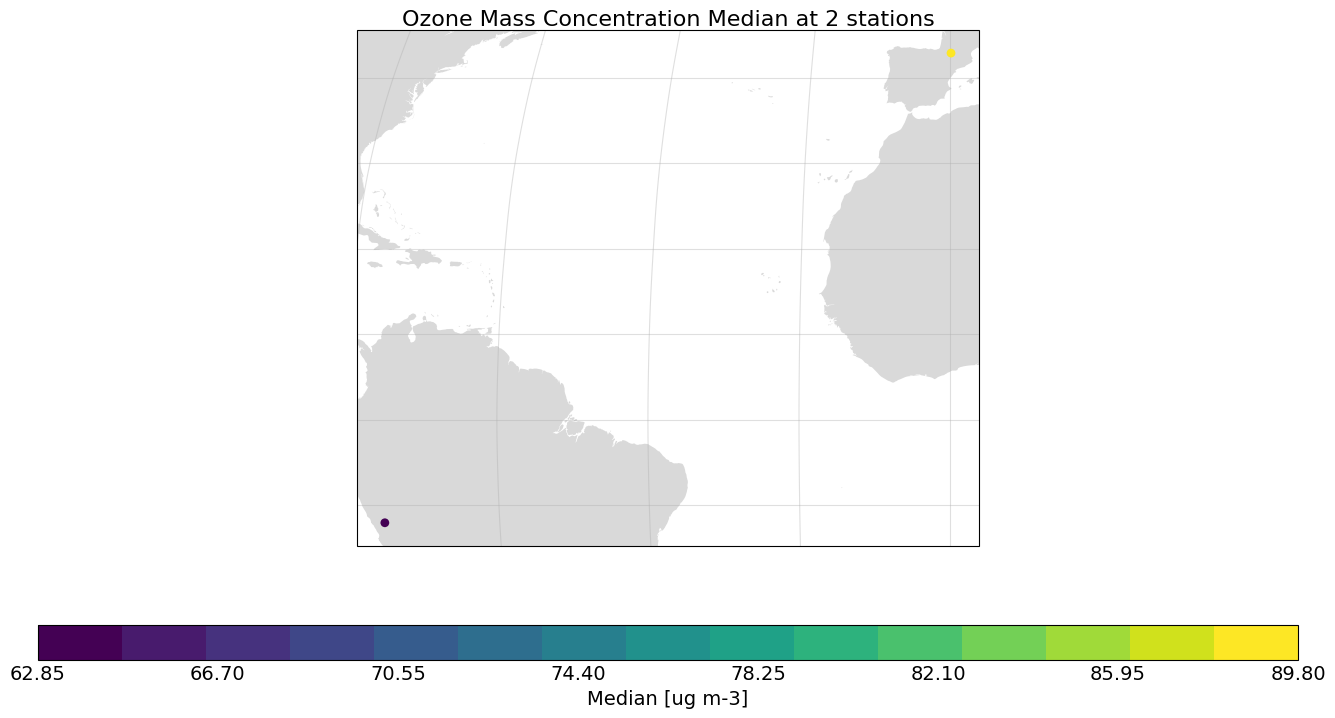

In [28]:
provi.plot('map-Median')